# Radial Chart

This section showcases the radial chart. It contains examples of how to create the radial chart using the [datachart.charts.RadialChart](../../../references/charts/#datachart.charts.RadialChart) function.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-radial-chart), which maps common tasks to the parameter or style attribute that does the job.

As mentioned above, the radial charts are created using the `RadialChart` function found in the [datachart.charts](../../../references/charts/) module. Let's import it:

In [1]:
from datachart.charts import RadialChart

## Radial Chart Input Attributes

The `RadialChart` function accepts keyword arguments for chart configuration. The main argument is `data`, which contains the data points, and `type`, which selects the visual the whole figure draws: `"line"` (default), `"bar"`, `"scatter"`, or `"histogram"`. For a single radial chart, `data` is a list of dictionaries. For multiple radial charts, `data` is a list of lists.

The line, bar, and scatter visuals take `label`/`y` points; the labels are placed evenly around the circle. The histogram visual instead takes numeric `x` observations in degrees, binned over [0, 360).

```python
RadialChart(
    data=[{                                             # A list of radial data points (or list of lists for multiple charts)
        "label": str,                                   # The category label (line, bar, and scatter visuals)
        "y":     Union[int, float],                     # The radial value (line, bar, and scatter visuals)
        "yerr":  Optional[Union[int, float]],           # The radial error value
        "x":     Optional[Union[int, float]]            # The angular observation in degrees (histogram visual)
    }],
    type=Optional[str],                                 # The visual: "line" (default), "bar", "scatter", or "histogram"
    style={                                             # The style of the marks (optional); each visual reads its cartesian family
        "plot_line_*":    ...,                          # the line visual (plus "plot_area_*" for fills and error bands)
        "plot_bar_*":     ...,                          # the bar visual
        "plot_scatter_*": ...,                          # the scatter visual
        "plot_hist_*":    ...,                          # the histogram visual
    },
    subtitle=Optional[str],                             # The subtitle of the chart (or list for multiple charts)
    emphasis=Optional[str],                             # "highlight" or "background" (or list for multiple charts)
    title=Optional[str],                                # The title of the chart
    xlabel=Optional[str],                               # The angular-axis label (the categories around the circle)
    ylabel=Optional[str],                               # The radial-axis label (the values)

    figsize=Optional[Tuple[float, float]],              # The figure size in inches
    show_grid=Optional[str],                            # Which grid lines to show ("both", "x", "y")
    show_legend=Optional[bool],                         # Whether to show the legend
    show_yerr=Optional[bool],                           # Whether to show the radial error band (line visual)
    show_area=Optional[bool],                           # Whether to fill the area inside the line (line visual)
    show_values=Optional[bool],                         # Whether to write each mark's value at its tip
    show_tip_labels=Optional[bool],                     # Whether to move the category labels to the mark tips
    show_border=Optional[bool],                         # Whether to draw the outer border circle
    value_format=Optional[str],                         # Format of the value labels (VALUE_FORMAT constant or e.g. "{:.1f}%")

    bar_mode=Optional[str],                             # How multiple bar series share the circle ("group", "stack", "overlay")
    num_bins=Optional[int],                             # Number of angular bins (histogram visual)
    startangle=Optional[Union[str, int, float]],        # Where the first label sits: a compass point ("N", "NE", ...) or degrees
    direction=Optional[str],                            # Which way the angles run ("clockwise", "counterclockwise")
    innerradius=Optional[float],                        # The donut hole, as a fraction (0-1) of the radial extent

    subplots=Optional[bool],                            # Whether to draw each chart in its own polar subplot
    max_cols=Optional[int],                             # Maximum number of subplots per row
    sharex=Optional[bool],                              # Whether subplots share the angular axis
    sharey=Optional[bool],                              # Whether subplots share the radial range
    scaley=Optional[str],                               # The radial-axis scale ("linear", "log", "symlog", "asinh")
    ymin=Optional[Union[int, float]],                   # The radial-axis range
    ymax=Optional[Union[int, float]],

    vspans=Optional[Union[dict, List[dict]]],           # the angular wedges to shade (bounds in degrees)
    hspans=Optional[Union[dict, List[dict]]],           # the annuli to shade (bounds in radial values)

    label=Optional[str],                                # the key holding the category label (default: "label")
    x=Optional[str],                                    # the key holding the angular observation (default: "x")
    y=Optional[str],                                    # the key holding the radial value (default: "y")
    yerr=Optional[str],                                 # the key holding the radial error value (default: "yerr")
)
```

For more details, see the [datachart.charts.RadialChart](../../../references/charts/#datachart.charts.RadialChart) function.

## Basics

The examples in this guide share one dataset: a year of weather measurements at a small coastal station. The data is hard-coded in a hidden cell; `wind_by_direction` holds the average wind speed for each of the eight compass directions (with the gust standard deviation as `yerr`), `wind_directions` holds the raw wind direction observations in degrees, and `sunshine_by_month` holds the monthly sunshine hours.

In [2]:
COMPASS = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# average wind speed (km/h) and gust standard deviation per compass direction
SPEED = [14.2, 11.6, 8.4, 7.1, 9.8, 17.5, 19.3, 16.8]
GUST_STD = [3.1, 2.6, 1.9, 1.6, 2.2, 4.0, 4.4, 3.8]
wind_by_direction = [
    {"label": d, "y": s, "yerr": g} for d, s, g in zip(COMPASS, SPEED, GUST_STD)
]

# raw wind direction observations in degrees (mostly south-westerly)
wind_directions = [
    {"x": float(deg % 360)}
    for deg in [
        225, 240, 232, 210, 250, 236, 228, 245, 218, 261, 233, 224, 249, 237,
        222, 255, 231, 226, 243, 219, 315, 308, 322, 298, 330, 312, 305, 45,
        38, 52, 29, 61, 44, 33, 57, 41, 180, 172, 195, 168, 202, 176, 90, 84,
        102, 78, 110, 95, 135, 128, 148, 121, 3, 352, 12, 344, 21, 336, 270,
        262, 281, 258, 289, 274, 225, 238, 229, 247, 216, 253, 234, 227,
    ]
]

# monthly sunshine hours
sunshine_by_month = [
    {"label": m, "y": h}
    for m, h in zip(MONTHS, [95, 118, 162, 194, 241, 268, 291, 275, 208, 154, 102, 84])
]

Each data point is a dictionary with a `label` (the compass direction) and a `y` value:

In [3]:
wind_by_direction[:3]

[{'label': 'N', 'y': 14.2, 'yerr': 3.1},
 {'label': 'NE', 'y': 11.6, 'yerr': 2.6},
 {'label': 'E', 'y': 8.4, 'yerr': 1.9}]

**Basic example.** Only the `data` argument is required to draw the radial chart.

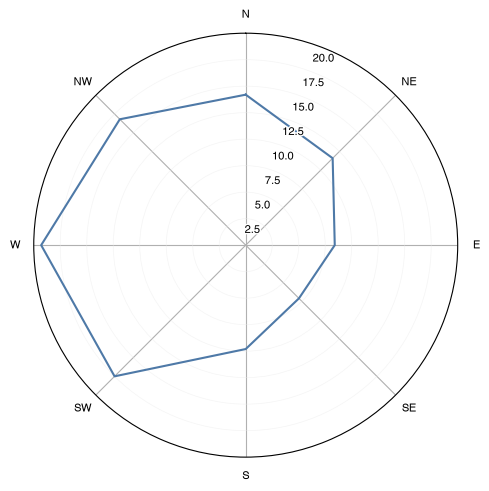

In [4]:
RadialChart(
    # add the data to the chart
    data=wind_by_direction
).show()

The labels are placed evenly around the circle, starting at the top (north) and running clockwise — the compass and clock convention. The line closes its own loop, and the radial value labels are drawn on top of the marks so they stay readable.

## Customizing the Radial Chart

Every customization is either a keyword argument of `RadialChart` or a style attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                | Use                                                | See |
| :---------------------------------------- | :------------------------------------------------- | :-- |
| add a title and axis labels               | `title`, `xlabel`, `ylabel`                        | [Title and axis labels](#title-and-axis-labels) |
| pick the visual                           | `type`                                             | [The radial visuals](#the-radial-visuals) |
| resize the figure or show the grid        | `figsize`, `show_grid`                             | [Figure size and grid](#figure-size-and-grid) |
| rotate where the circle starts            | `startangle`                                       | [Start angle and direction](#start-angle-and-direction) |
| flip the angular direction                | `direction`                                        | [Start angle and direction](#start-angle-and-direction) |
| cut a donut hole in the middle            | `innerradius`                                      | [Inner radius](#inner-radius) |
| style the marks                           | `style` with the visual's `plot_*` attributes      | [Mark style](#mark-style) |
| highlight or mute a series                | `emphasis`                                         | [Emphasis](#emphasis) |
| stack multiple bar series                 | `bar_mode`                                         | [Bar mode](#bar-mode) |
| split series into their own subplots      | `subplots`, `max_cols`                             | [Subplots](#subplots) |
| show an error band or fill the area       | `show_yerr`, `show_area`                           | [Error bands and filled areas](#error-bands-and-filled-areas) |
| write values or labels at the mark tips   | `show_values`, `show_tip_labels`                   | [Values and labels at the tips](#values-and-labels-at-the-tips) |
| hide the outer border circle              | `show_border`                                      | [Values and labels at the tips](#values-and-labels-at-the-tips) |
| use a log radial axis                     | `scaley`                                           | [Radial axis scale](#radial-axis-scale) |
| shade a wedge or an annulus               | `vspans`, `hspans`                                 | [Reference bands](#reference-bands) |

The parameters that accept a constant, with the class in [datachart.constants](../../../references/constants/) that lists its values:

| Parameter | Constant |
| :-- | :-- |
| `type` | [`RADIAL_TYPE`](../../../references/constants/#datachart.constants.RADIAL_TYPE) |
| `direction` | [`RADIAL_DIRECTION`](../../../references/constants/#datachart.constants.RADIAL_DIRECTION) |
| `emphasis` | [`EMPHASIS`](../../../references/constants/#datachart.constants.EMPHASIS) |
| `figsize` | [`FIG_SIZE`](../../../references/constants/#datachart.constants.FIG_SIZE) |
| `legend={"location": ..., "alignment": ...}` | [`LEGEND_LOCATION`](../../../references/constants/#datachart.constants.LEGEND_LOCATION), [`LEGEND_ALIGN`](../../../references/constants/#datachart.constants.LEGEND_ALIGN) |
| `show_grid` | [`SHOW_GRID`](../../../references/constants/#datachart.constants.SHOW_GRID) |
| `bar_mode` | [`BAR_MODE`](../../../references/constants/#datachart.constants.BAR_MODE) |
| `sort` | [`SORT`](../../../references/constants/#datachart.constants.SORT) |
| `scaley` | [`SCALE`](../../../references/constants/#datachart.constants.SCALE) |

### Title and axis labels

To add the chart title and axis labels, add the `title`, `xlabel` and `ylabel` attributes. On a polar plot the `xlabel` describes the angular axis (the categories around the circle) and the `ylabel` the radial axis (the values). The radial range can be fixed with `ymin` and `ymax`.

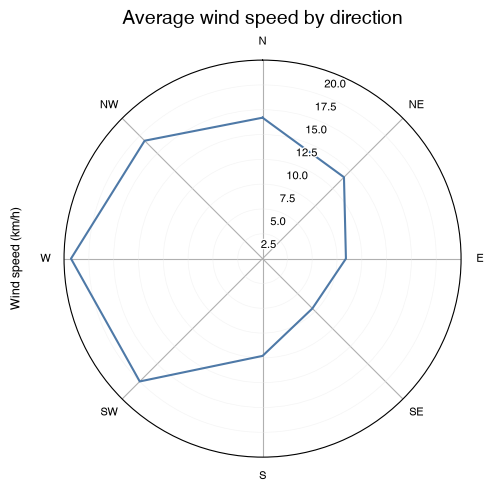

In [5]:
RadialChart(
    data=wind_by_direction,
    # add the title and the axis labels
    title="Average wind speed by direction",
    ylabel="Wind speed (km/h)",
    ymin=0,
).show()

### The radial visuals

The `type` attribute selects the mark family the whole figure draws. To help with the options settings, the [datachart.constants](../../../references/constants) module provides the `RADIAL_TYPE` constant.

| Options                   | Description |
| :------------------------ | :---------- |
| `RADIAL_TYPE.LINE`        | The line (radar) visual. Default. |
| `RADIAL_TYPE.BAR`         | The bar visual, one sector per label. |
| `RADIAL_TYPE.SCATTER`     | The scatter visual. |
| `RADIAL_TYPE.HISTOGRAM`   | The angular histogram (wind rose) visual, binning degree observations over [0, 360). |

In [6]:
from datachart.constants import RADIAL_TYPE

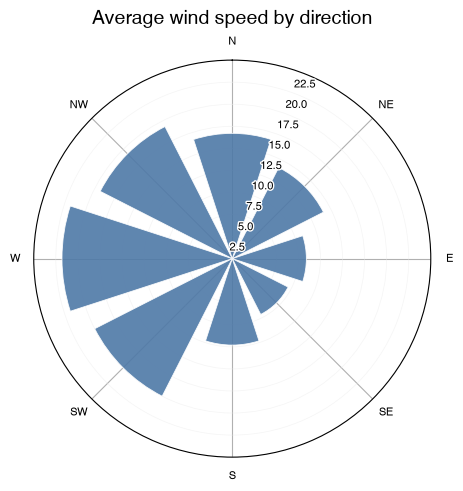

In [7]:
RadialChart(
    data=wind_by_direction,
    # draw one bar sector per compass direction
    type=RADIAL_TYPE.BAR,
    title="Average wind speed by direction",
).show()

The histogram visual takes raw angular observations in degrees and bins them over the full circle; the `num_bins` attribute sets the number of angular bins. This is the classic wind rose:

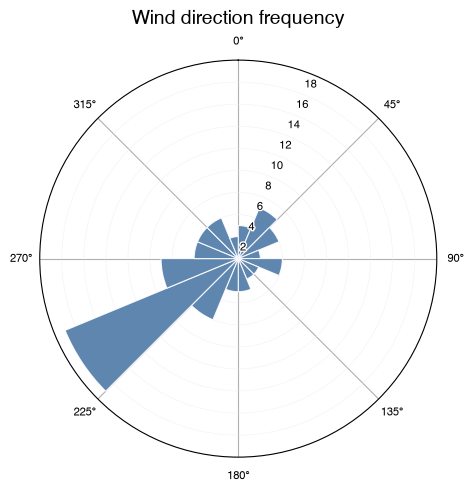

In [8]:
RadialChart(
    data=wind_directions,
    type=RADIAL_TYPE.HISTOGRAM,
    # bin the directions into 16 sectors over the full circle
    num_bins=16,
    title="Wind direction frequency",
).show()

### Figure size and grid

The figure size is set with `figsize` — the [datachart.constants](../../../references/constants) module provides the `FIG_SIZE` options — and the polar grid is turned on with `show_grid`. The grid is always drawn below the marks, so bars never hide behind grid lines.

In [9]:
from datachart.constants import FIG_SIZE, SHOW_GRID

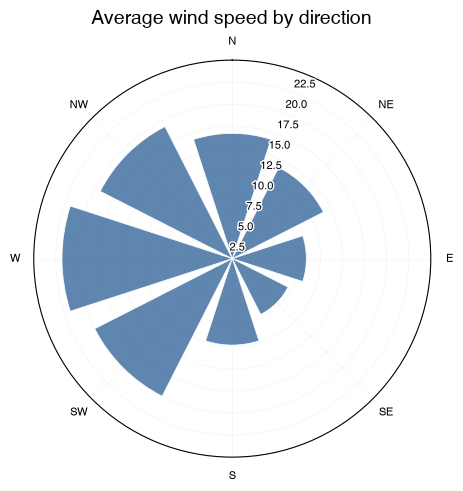

In [10]:
RadialChart(
    data=wind_by_direction,
    type=RADIAL_TYPE.BAR,
    title="Average wind speed by direction",
    # resize the figure and show the full polar grid
    figsize=FIG_SIZE.SQUARE,
    show_grid=SHOW_GRID.BOTH,
).show()

### Start angle and direction

By default the first label sits at the top (north) and the angles run clockwise. The `startangle` attribute moves the starting point — either a compass location (`"N"`, `"NE"`, `"E"`, `"SE"`, `"S"`, `"SW"`, `"W"`, `"NW"`) or a numeric compass bearing in degrees clockwise from north. The `direction` attribute flips which way the angles increase; the [datachart.constants](../../../references/constants) module provides the `RADIAL_DIRECTION` constant with the `CLOCKWISE` and `COUNTERCLOCKWISE` options.

In [11]:
from datachart.constants import RADIAL_DIRECTION

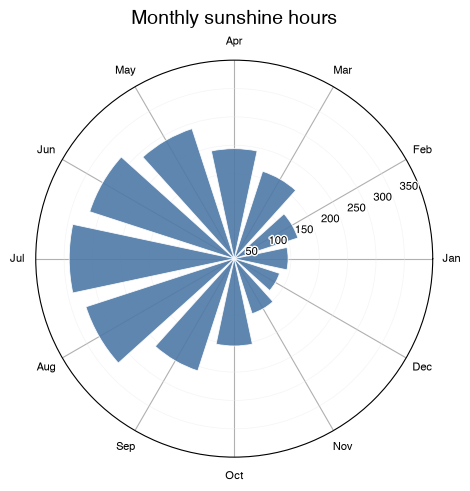

In [12]:
RadialChart(
    data=sunshine_by_month,
    type=RADIAL_TYPE.BAR,
    title="Monthly sunshine hours",
    # start at the right and run counterclockwise (the math convention)
    startangle="E",
    direction=RADIAL_DIRECTION.COUNTERCLOCKWISE,
).show()

### Inner radius

The `innerradius` attribute cuts a donut hole in the middle of the chart — a fraction between 0 and 1 of the radial extent. A hole keeps the innermost values readable, since sectors near the center otherwise shrink to slivers.

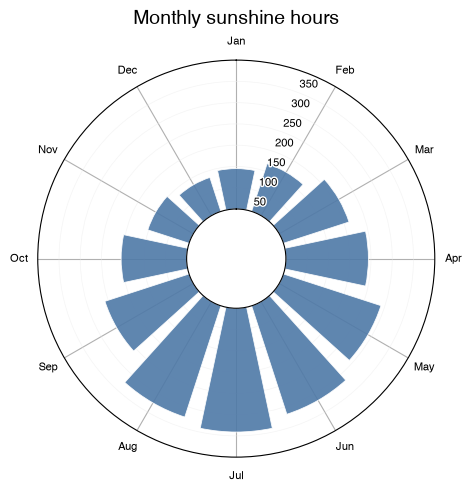

In [13]:
RadialChart(
    data=sunshine_by_month,
    type=RADIAL_TYPE.BAR,
    title="Monthly sunshine hours",
    # reserve the middle 25% of the radius for the hole
    innerradius=0.25,
).show()

### Mark style

Radial marks obey the same style attributes as their cartesian cousins: the line visual reads `plot_line_*` (and `plot_area_*` for fills), the bar visual `plot_bar_*`, the scatter visual `plot_scatter_*`, and the histogram visual `plot_hist_*`. See the [datachart.typings](../../../references/typings) module for the attributes of each style family. Themes therefore style radial charts out of the box.

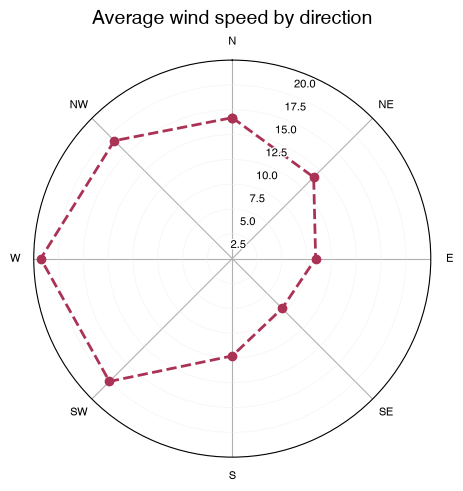

In [14]:
RadialChart(
    data=wind_by_direction,
    title="Average wind speed by direction",
    # style the line just like a cartesian line chart
    style={
        "plot_line_color": "#aa3355",
        "plot_line_width": 2,
        "plot_line_style": "--",
        "plot_line_marker": "o",
    },
).show()

### Emphasis

When a chart carries several series, the story is often about one of them. The `emphasis` attribute expresses that directly: `"highlight"` bolds a series and brings it to the front, `"background"` mutes a series (the theme's muted color at a lower alpha, drawn behind the others and left out of the legend), and `None` leaves a series unchanged. For multiple charts, `emphasis` is a list aligned with `data`, just like `subtitle` and `style`.

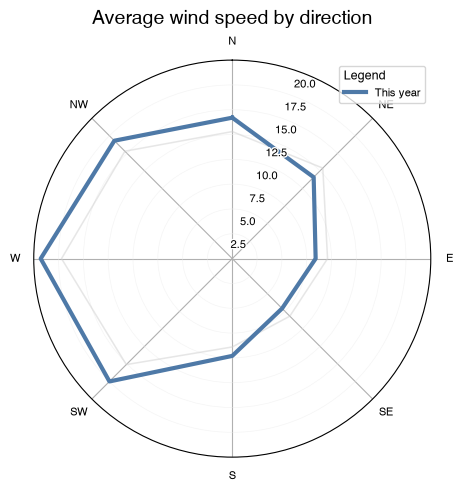

In [15]:
# the same station in two years: this year is the story
wind_last_year = [
    {"label": d, "y": s}
    for d, s in zip(COMPASS, [12.8, 12.9, 9.6, 8.2, 8.9, 15.1, 17.2, 15.3])
]
wind_this_year = [{"label": p["label"], "y": p["y"]} for p in wind_by_direction]

RadialChart(
    data=[wind_last_year, wind_this_year],
    subtitle=["Last year", "This year"],
    # mute last year, highlight this year
    emphasis=["background", "highlight"],
    title="Average wind speed by direction",
    show_legend=True,
).show()

On the bar visual, emphasis can also come from the values. `sort` orders the sectors around the circle by value (`"ascending"` or `"descending"`; the [datachart.constants.SORT](../../../references/constants/#datachart.constants.SORT) constants), one order for every series, and `emphasis_rule` highlights the bars matching a one-key rule — `{"above": v}`, `{"below": v}`, `{"between": (lo, hi)}`, `{"top": n}`, or `{"bottom": n}` — and mutes the rest. A data point's own `"emphasis"` key wins over the rule. The example orders the directions by speed and picks out the ones averaging above 15 km/h.

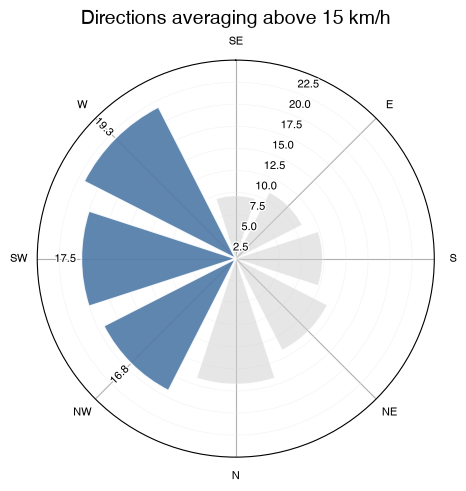

In [16]:
from datachart.constants import SORT

RadialChart(
    data=wind_by_direction,
    type=RADIAL_TYPE.BAR,
    title="Directions averaging above 15 km/h",
    # sectors in order of speed, clockwise from the start angle
    sort=SORT.ASCENDING,
    # highlight the strong directions, mute the rest
    emphasis_rule={"above": 15},
    show_values=True,
    value_format="%.1f",
).show()

## Multiple Radial Charts

To plot multiple radial charts in the same figure, pass a list of lists as `data`. All series share the figure's one `type`; to mix visuals in one polar plot, compose rendered figures with [datachart.utils.Panel](../../../references/utils#datachart.utils.Panel).

### Sub-chart subtitles

The `subtitle` attribute names the individual series; with `show_legend=True` the names appear in the legend.

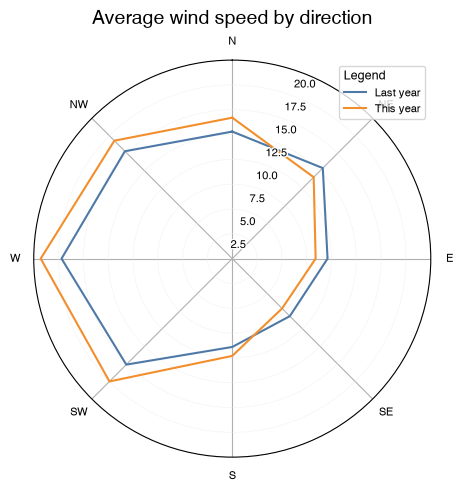

In [17]:
RadialChart(
    data=[wind_last_year, wind_this_year],
    # add the subtitles and show the legend
    subtitle=["Last year", "This year"],
    show_legend=True,
    title="Average wind speed by direction",
).show()

### Bar mode

Multiple bar series share the circle the same way cartesian bars share the axis, via `bar_mode`: `"group"` (side-by-side within each sector, the default), `"stack"` (on top of each other), or `"overlay"`. The [datachart.constants](../../../references/constants) module provides the `BAR_MODE` constant.

In [18]:
from datachart.constants import BAR_MODE

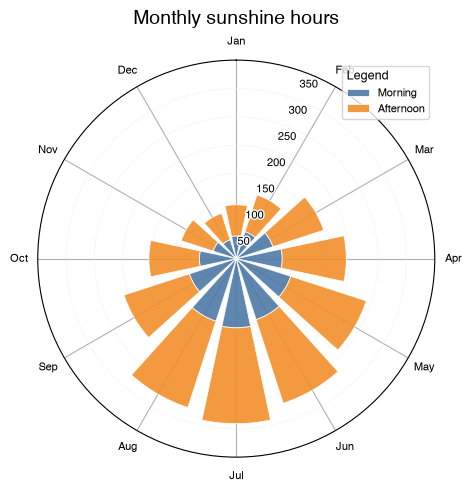

In [19]:
# sunshine hours split into morning and afternoon
morning = [{"label": p["label"], "y": round(p["y"] * 0.42)} for p in sunshine_by_month]
afternoon = [{"label": p["label"], "y": round(p["y"] * 0.58)} for p in sunshine_by_month]

RadialChart(
    data=[morning, afternoon],
    type=RADIAL_TYPE.BAR,
    # stack the two series in each sector
    bar_mode=BAR_MODE.STACK,
    subtitle=["Morning", "Afternoon"],
    show_legend=True,
    title="Monthly sunshine hours",
).show()

### Subplots

To display each series in its own polar subplot, set `subplots=True`. The `max_cols` attribute controls how many subplots sit in one row, and `sharey=True` gives every subplot the same radial range so the shapes stay comparable.

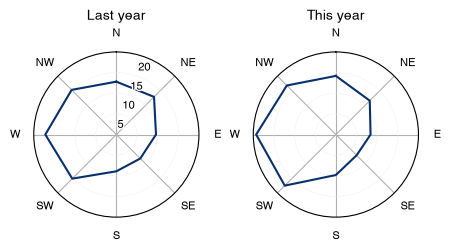

In [20]:
RadialChart(
    data=[wind_last_year, wind_this_year],
    subtitle=["Last year", "This year"],
    # one polar subplot per series, sharing the radial range
    subplots=True,
    max_cols=2,
    sharey=True,
    figsize=FIG_SIZE.FULL_SHORT,
).show()

## Additional Features

### Error bands and filled areas

The line visual supports the same enrichments as the line chart: `show_yerr=True` draws a band of `yerr` around the line, and `show_area=True` fills the polygon the line encloses.

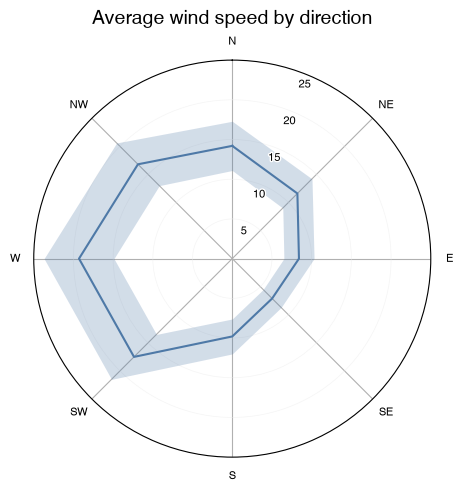

In [21]:
RadialChart(
    data=wind_by_direction,
    # draw the gust standard deviation as a band around the line
    show_yerr=True,
    title="Average wind speed by direction",
).show()

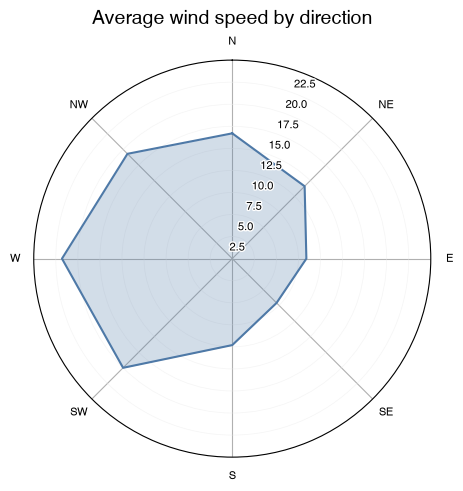

In [22]:
RadialChart(
    data=wind_by_direction,
    # fill the polygon the line encloses
    show_area=True,
    title="Average wind speed by direction",
).show()

### Values and labels at the tips

The `show_values` attribute writes each mark's value at its tip, rotated along the spoke (formatted via `value_format`, exactly like the bar chart's value labels). The `show_tip_labels` attribute instead moves the category labels from the ring around the circle to the mark tips — each label hugs the outermost mark on its spoke and flips on the left half so it always reads outward. Together with `show_border=False`, which hides the outer border circle, this gives the classic circular-barplot look.

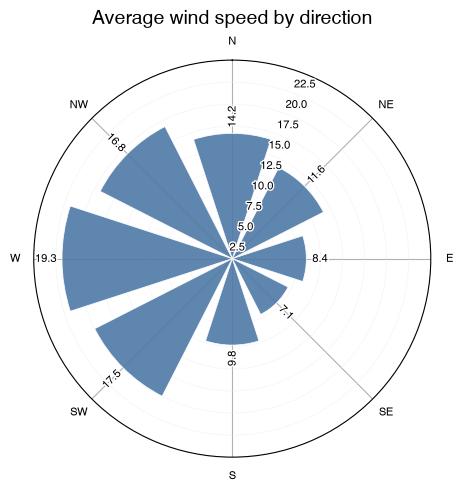

In [23]:
RadialChart(
    data=wind_by_direction,
    type=RADIAL_TYPE.BAR,
    # write each bar's value at its tip
    show_values=True,
    value_format="%.1f",
    title="Average wind speed by direction",
).show()

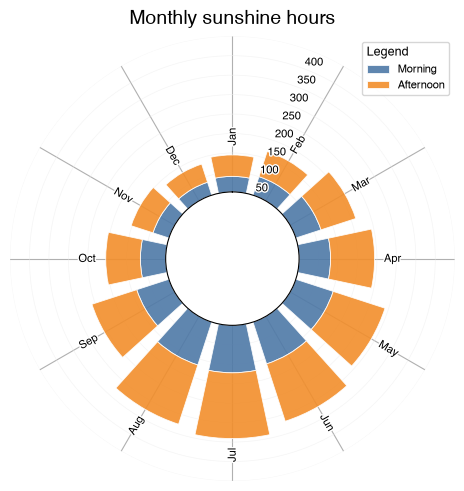

In [24]:
RadialChart(
    data=[morning, afternoon],
    type=RADIAL_TYPE.BAR,
    bar_mode=BAR_MODE.STACK,
    # the month labels ride the bar tips; no border circle
    show_tip_labels=True,
    show_border=False,
    innerradius=0.3,
    subtitle=["Morning", "Afternoon"],
    show_legend=True,
    title="Monthly sunshine hours",
    figsize=FIG_SIZE.SQUARE,
).show()

### Radial axis scale

The radial (value) axis can change scale with `scaley`, exactly like a cartesian y-axis. The angular axis has no scale to change — passing `scalex` raises a `ValueError`, as do `vlines` and `hlines`, which have no geometric meaning on a polar plot. Shaded [reference bands](#reference-bands) do have one, and are supported.

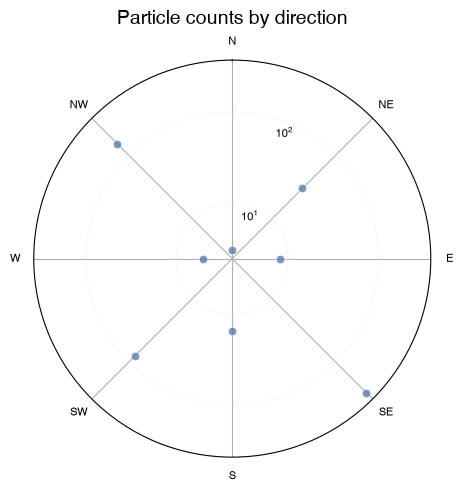

In [25]:
from datachart.constants import SCALE

RadialChart(
    data=[{"label": d, "y": y} for d, y in zip(COMPASS, [3, 30, 8, 300, 15, 80, 5, 150])],
    type=RADIAL_TYPE.SCATTER,
    # spread values spanning two orders of magnitude
    scaley=SCALE.LOG,
    title="Particle counts by direction",
).show()

### Reference bands

A straight reference line has no meaning on a polar plot, but a shaded band does. The `vspans` argument draws an angular **wedge** over the full radius, bounded by `xmin` and `xmax` in degrees measured from the start angle in the chart's direction; the `hspans` argument draws an **annulus** over the full circle, bounded by `ymin` and `ymax` in radial values. Both use the [datachart.typings.VSpanSettingAttrs](../../../references/typings/#datachart.typings.VSpanSettingAttrs) and [datachart.typings.HSpanSettingAttrs](../../../references/typings/#datachart.typings.HSpanSettingAttrs) typings of the cartesian charts: a `label` puts the band in the legend, `style` takes the `plot_vspan_*` / `plot_hspan_*` attributes, and an omitted bound runs to the edge (0° or 360° for a wedge, the radial minimum or maximum for an annulus).

The example shades the south-westerly quadrant, where the wind is strongest, and the 10–15 km/h speed range.


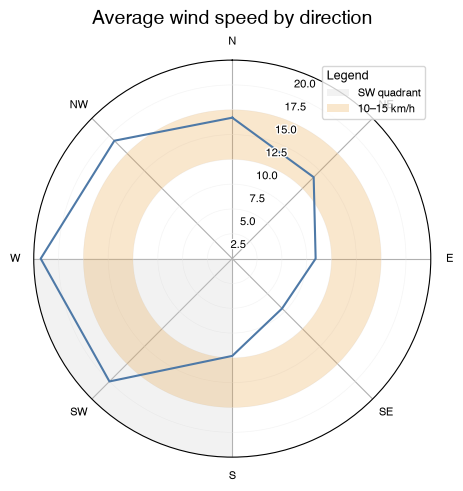

In [26]:
RadialChart(
    data=wind_by_direction,
    # a wedge from south (180°) to west (270°), measured from the start angle
    vspans={"xmin": 180, "xmax": 270, "label": "SW quadrant"},
    # an annulus between 10 and 15 km/h
    hspans={
        "ymin": 10,
        "ymax": 15,
        "label": "10–15 km/h",
        "style": {"plot_hspan_color": "#e9a03b"},
    },
    title="Average wind speed by direction",
    show_legend=True,
).show()

## Saving the Chart as an Image

To save the chart as an image, use the [datachart.utils.save_figure](../../../references/utils#datachart.utils.save_figure) function.

In [27]:
from datachart.utils import save_figure

In [28]:
figure = RadialChart(
    data=wind_by_direction,
    title="Average wind speed by direction",
)
save_figure(figure, "./fig_radial_chart.png", dpi=300)

['./fig_radial_chart.png']

The figure should be saved in the current working directory.

## Real-World Examples

### Example 1: Wind Rose (Angular Histogram)

The classic use of a radial chart: how often the wind blows from each direction. The raw degree observations are binned into 16 sectors; the compass start angle and clockwise direction are the defaults.

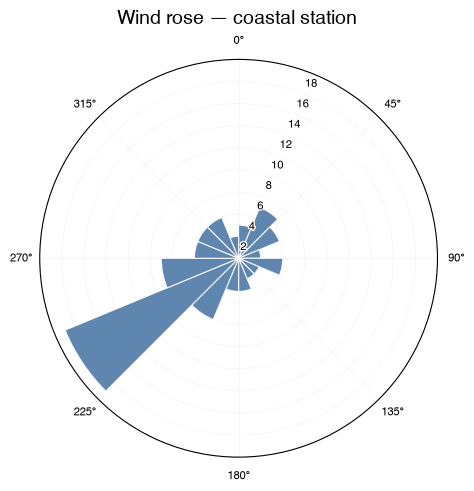

In [29]:
RadialChart(
    data=wind_directions,
    type=RADIAL_TYPE.HISTOGRAM,
    num_bins=16,
    title="Wind rose — coastal station",
    figsize=FIG_SIZE.SQUARE,
    show_grid=SHOW_GRID.BOTH,
).show()

### Example 2: Skill Radar (Line with Area)

A radar (spider) chart comparing two profiles over the same skill set. The filled areas make the overall footprint of each profile easy to compare, and the legend names them.

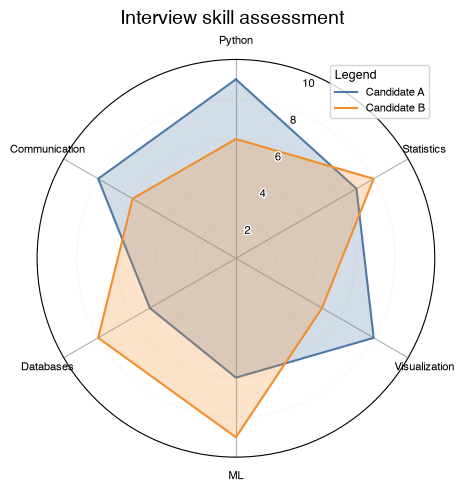

In [30]:
SKILLS = ["Python", "Statistics", "Visualization", "ML", "Databases", "Communication"]
candidate_a = [{"label": s, "y": y} for s, y in zip(SKILLS, [9, 7, 8, 6, 5, 8])]
candidate_b = [{"label": s, "y": y} for s, y in zip(SKILLS, [6, 8, 5, 9, 8, 6])]

RadialChart(
    data=[candidate_a, candidate_b],
    subtitle=["Candidate A", "Candidate B"],
    show_area=True,
    show_legend=True,
    ymin=0,
    ymax=10,
    title="Interview skill assessment",
    figsize=FIG_SIZE.SQUARE,
).show()

### Example 3: Seasonal Activity Clock (Stacked Donut Bars)

Monthly visitor numbers at a mountain hut, split by weekday and weekend visits. The stacked bars run like a clock — January at the top, months clockwise — and the donut hole keeps the quiet winter months readable.

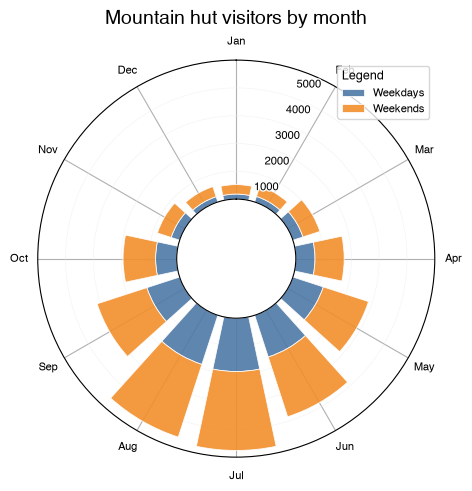

In [31]:
weekday_visits = [
    {"label": m, "y": v}
    for m, v in zip(MONTHS, [180, 210, 380, 690, 1150, 1580, 1920, 1860, 1240, 760, 320, 200])
]
weekend_visits = [
    {"label": m, "y": v}
    for m, v in zip(MONTHS, [340, 390, 640, 1050, 1710, 2260, 2840, 2750, 1880, 1170, 520, 380])
]

RadialChart(
    data=[weekday_visits, weekend_visits],
    type=RADIAL_TYPE.BAR,
    bar_mode=BAR_MODE.STACK,
    subtitle=["Weekdays", "Weekends"],
    show_legend=True,
    innerradius=0.3,
    title="Mountain hut visitors by month",
    figsize=FIG_SIZE.SQUARE,
).show()